In [14]:
import math
from poisson_process import CompoundPoisson, CramerLundberg, NonHomogeneousPoissonProcess
from poisson_process import PoissonProcess1, PoissonProcess2, PoissonProcess3
from poisson_process import torch

# **Proceso Poisson**

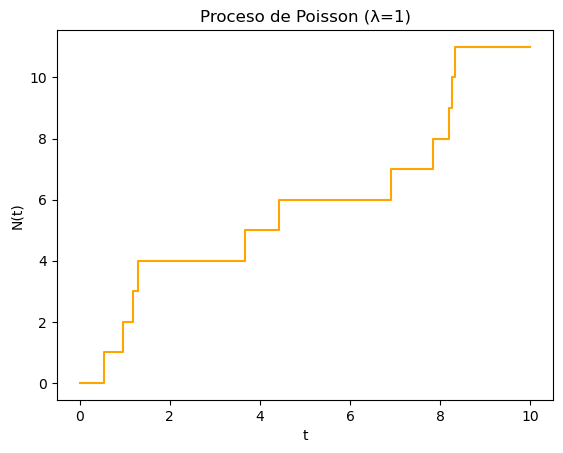

In [2]:
poi_p = PoissonProcess1(1)
poi_p.plot(10,color='orange',linestyle="-")

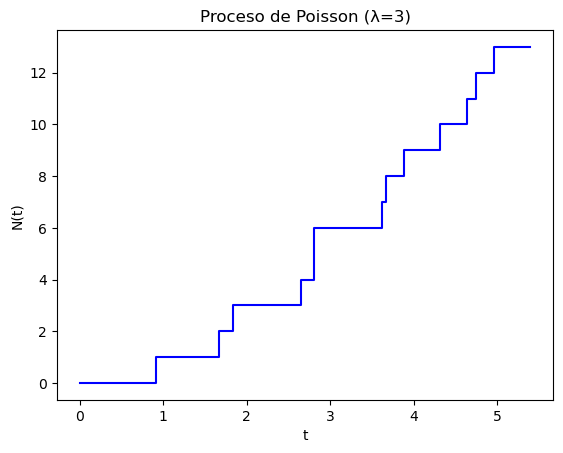

In [3]:
poi_p2 = PoissonProcess2(3)
poi_p2.plot(5.4,100)

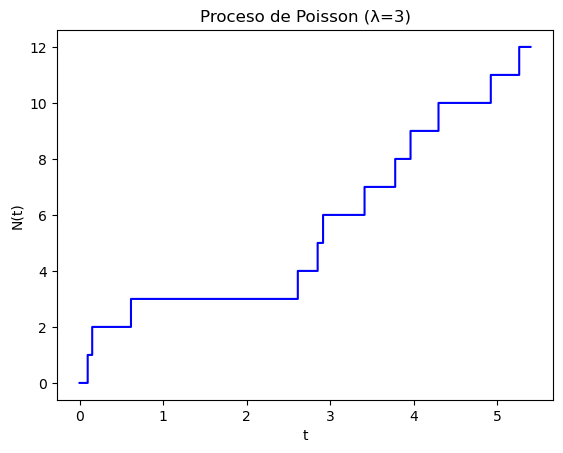

In [4]:
poi_p2 = PoissonProcess2(3)
poi_p2.plot(5.4,1000)

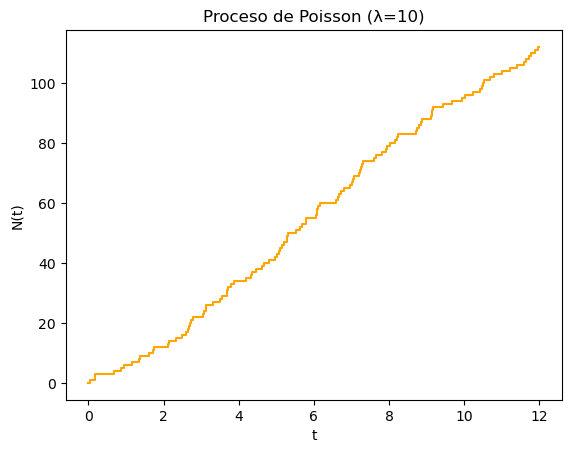

In [5]:
pp3 = PoissonProcess3(10)
pp3.plot(12,color="orange")

# **Proceso Poisson No Homogeneo**

In [6]:
def lamb(x):
    return 0.5*x

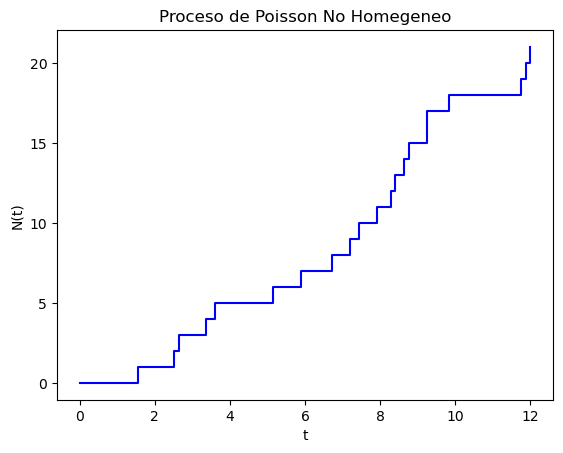

In [8]:
nh_pp = NonHomogeneousPoissonProcess(lamb)
nh_pp.plot(12,100)

In [9]:
def lam2(x):
    return 5-0.1*(x-6)**2

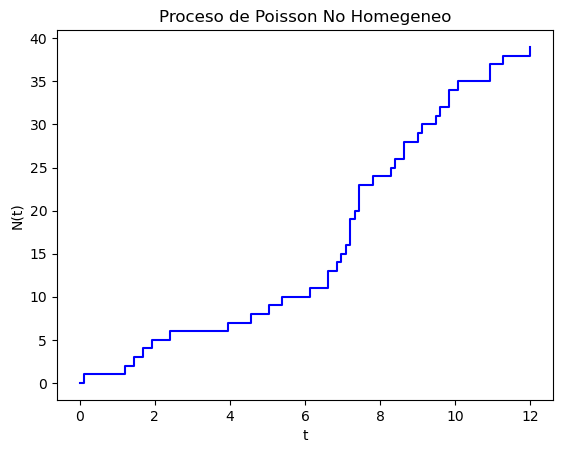

In [10]:
nh_pp = NonHomogeneousPoissonProcess(lam2)
nh_pp.plot(12,100)

In [11]:
def lam3(x):
    return 3 +2*math.sin(math.pi*x/12)

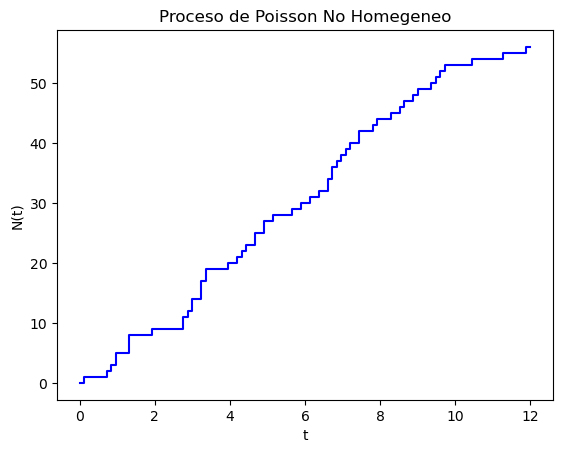

In [12]:
nh_pp = NonHomogeneousPoissonProcess(lam3)
nh_pp.plot(12,100)

# **Proceso Poisson Compuesto**

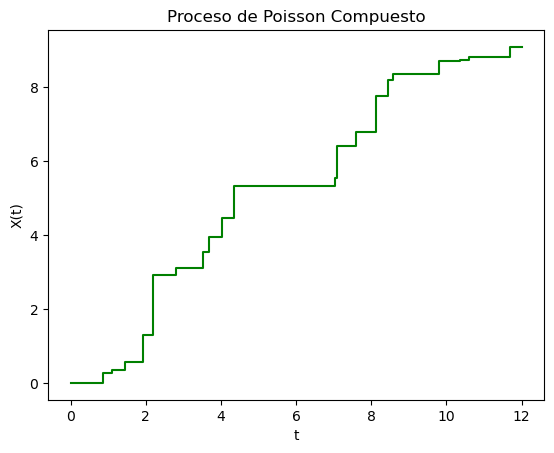

In [17]:
lam = 2

# saltos exponenciales
jump_dist = torch.distributions.Exponential(2.5)

cp = CompoundPoisson(lam, jump_dist)
cp.plot(12,'green','-')

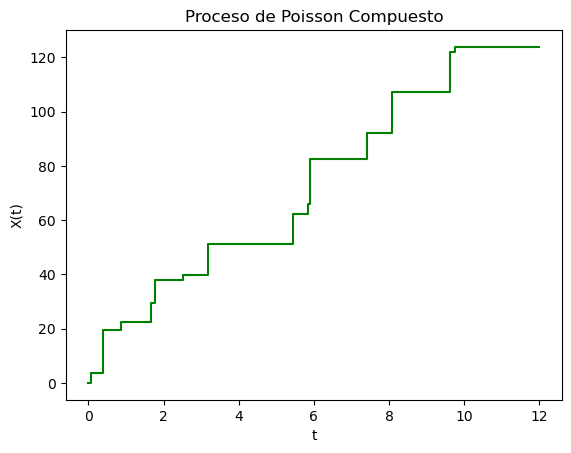

In [18]:
lam = 2
beta = 1/2.4
alpha = 3.5

# saltos exponenciales
jump_dist = torch.distributions.Gamma(alpha,beta)

cp = CompoundPoisson(lam, jump_dist)
cp.plot(12,'green','-')

# **Modelo de Cramer Lundberg**

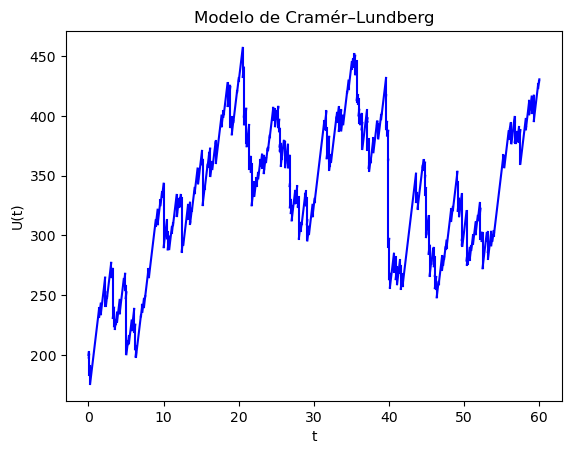

In [19]:
lam = 5
u = 200
beta = 1/10
i = 0.05
c = (1+i)*lam*(1/beta)
t = 12*5

# saltos exponenciales
claim_dist = torch.distributions.Exponential(beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

In [20]:
P = cl_p.ruin_probability(t,10000)
print(f"Probabilidad de ruina: {P[0]},\nIntervalo del 95% de confianza: {P[1:]}")

Probabilidad de ruina: 0.2312,
Intervalo del 95% de confianza: (0.22293679184117912, 0.23946320815882086)


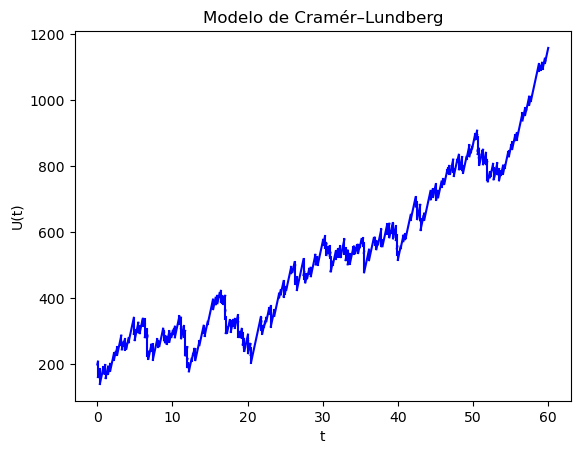

In [21]:
lam = 5
u = 200
beta = 1/10
alpha = 2
i = 0.05
c = (1+i)*lam*(alpha/beta)
t = 12*5

# saltos exponenciales
claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

In [22]:
P = cl_p.ruin_probability(t,10000)
print(f"Probabilidad de ruina: {P[0]},\nIntervalo del 95% de confianza: {P[1:]}")

Probabilidad de ruina: 0.4115,
Intervalo del 95% de confianza: (0.4018549108903797, 0.42114508910962023)


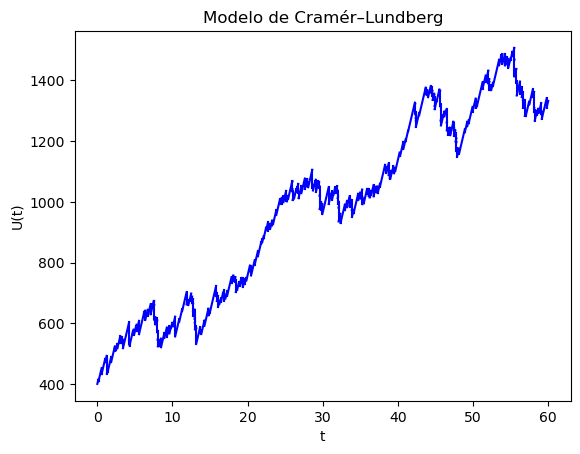

In [23]:
lam = 5
u = 400
beta = 1/10
alpha = 2
i = 0.05
c = (1+i)*lam*(alpha/beta)
t = 12*5

# saltos exponenciales
claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

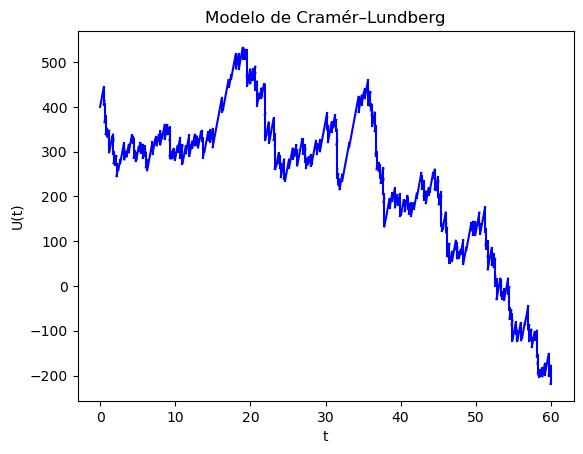

In [25]:
lam = 5
u = 400
beta = 1/10
alpha = 2
i = 0.1
c = (1-i)*lam*(alpha/beta)
t = 12*5

# saltos exponenciales
claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

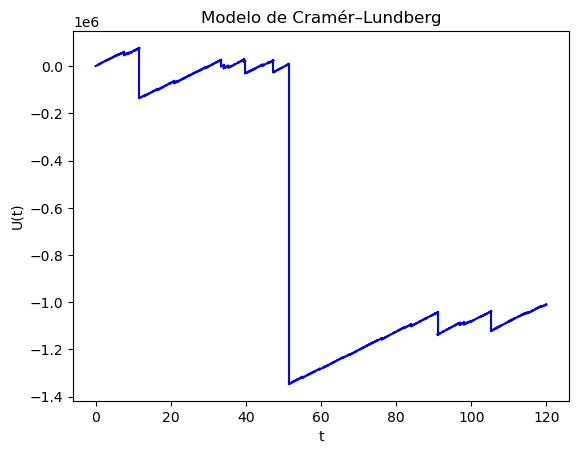

In [35]:
lam = 5
u = 500
mu = 1
sigma = 4
i = 0.05
c = (1+i)*math.exp(mu+(sigma**2)/2)
t = 12*10

# saltos exponenciales
claim_dist = torch.distributions.LogNormal(mu,sigma)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

In [36]:
P = cl_p.ruin_probability(t,10000)
print(f"Probabilidad de ruina: {P[0]},\nIntervalo del 95% de confianza: {P[1:]}")

Probabilidad de ruina: 0.8613,
Intervalo del 95% de confianza: (0.8545257137313957, 0.8680742862686042)


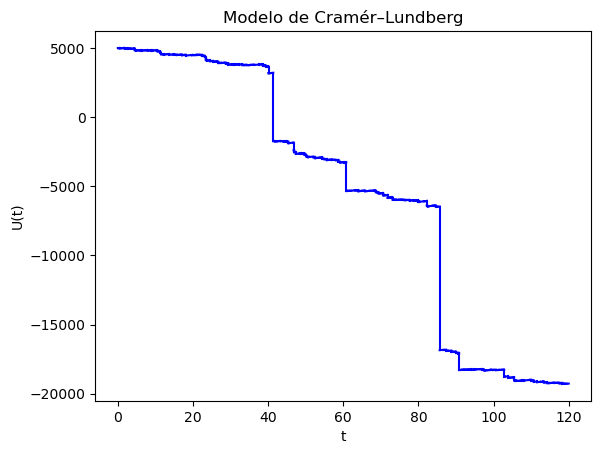

In [45]:
lam = 5
u = 5000
mu = 1
sigma = 2
i = 0.5
c = (1+i)*math.exp(mu+(sigma**2)/2)
t = 12*10

# saltos exponenciales
claim_dist = torch.distributions.LogNormal(mu,sigma)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

In [46]:
P = cl_p.ruin_probability(t,10000)
print(f"Probabilidad de ruina: {P[0]},\nIntervalo del 95% de confianza: {P[1:]}")

Probabilidad de ruina: 0.9357,
Intervalo del 95% de confianza: (0.9308924712263881, 0.9405075287736119)


24.1026443078252